In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 9.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ultralytics
import yaml

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
DATASET_ROOT = Path(
    "/content/datasets"
)

DATA_YAML_PATH = Path("/content/drive/MyDrive/vision_unit_02_outputs/block_02/crack_seg_local.yaml")

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_04"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_NAME = "yolo26n_crack_seg_v1"
RUN_DIRECTORY = OUTPUT_ROOT / RUN_NAME


BEST_MODEL_PATH = (
    RUN_DIRECTORY
    / "weights"
    / "best.pt"
)

LAST_MODEL_PATH = (
    RUN_DIRECTORY
    / "weights"
    / "last.pt"
)

print("Dataset YAML:", DATA_YAML_PATH)
print("Output:", OUTPUT_ROOT)

Dataset YAML: /content/drive/MyDrive/vision_unit_02_outputs/block_02/crack_seg_local.yaml
Output: /content/drive/MyDrive/vision_unit_02_outputs/block_04


**Verify dataset configuration**

In [5]:
with DATA_YAML_PATH.open("r", encoding="utf-8") as file:
    dataset_config = yaml.safe_load(file)

print(yaml.safe_dump(dataset_config,sort_keys=False))

path: /content/datasets
train: images/train
val: images/val
test: images/test
names:
  0: crack



**Confirm pairing counts**

In [8]:
for split_name, expected_count in {
    "train": 3717,
    "val": 200,
    "test": 112,
}.items():
    image_directory = DATASET_ROOT / "images" / split_name
    label_directory = DATASET_ROOT / "labels" / split_name
    
    image_count = len(list(
        image_directory.glob("*.*")
    ))
    label_count = len(list(
        label_directory.glob("*.txt")
    ))
    
    print(split_name, "| images:", image_count, "| labels:", label_count)

    assert image_count == expected_count
    assert label_count == expected_count

train | images: 3717 | labels: 3717
val | images: 200 | labels: 200
test | images: 112 | labels: 112


**Load the segmentation model**

In [10]:
model = YOLO("yolo26n-seg.pt")
print("Task : ", model.task)

model.info()

Task :  segment
YOLO26n-seg summary: 309 layers, 3,126,280 parameters, 0 gradients, 10.6 GFLOPs


(309, 3126280, 0, 10.6303744)

**Training configuration**

In [11]:
TRAINING_CONFIG = {
    "data" : str(DATA_YAML_PATH),
    "epochs" : 40,
    "patience" : 8,
    "imgsz" : 416,
    "batch" : 16,
    "device" : 0,
    "workers" : 2,
    
    "optimizer" : "AdamW",
    "lr0" : 1e-3,
    "weight_decay" : 5e-4,
    "warmup_epochs" : 2.0,
    "cos_lr" : True,
    
    "degrees" : 10.0,
    "translate": 0.05,
    "scale": 0.20,
    "fliplr": 0.50,
    "flipud": 0.50,
    
    "mosaic": 0.50,
    "close_mosaic": 5,
    "mixup": 0.0,
    "copy_paste": 0.0,

    "mask_ratio": 2,
    "overlap_mask": False,
    
    "nms" : True,
    "seed": 42,
    "deterministic": True,
    "amp": True,
    "cache": False,
    "plots": True,
    "save": True,
    "project": str(OUTPUT_ROOT),
    "name": RUN_NAME,
    "exist_ok": True,
}

**Start fresh training**

In [12]:
if LAST_MODEL_PATH.is_file():
    print("Existing checkpoint found:", LAST_MODEL_PATH)

else:
    model = YOLO("yolo26n-seg.pt")
    training_results = model.train(**TRAINING_CONFIG)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/vision_unit_02_outputs/block_02/crack_seg_local.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, na

In [ ]:
# -> If training interrupt
# resume_model = YOLO(str(LAST_MODEL_PATH))

# resume_results = resume_model.train(resume=True)

### Validation

**Fair validation**

In [14]:
best_model = YOLO(str(BEST_MODEL_PATH))

validation_metrics = best_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=416,
    batch=16,
    device=0,
    workers=2,
    rect=False,
    nms=True,
    plots=True,
    project=str(OUTPUT_ROOT),
    name="validation",
    exist_ok=True
)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,689,079 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 673.2±231.1 MB/s, size: 19.5 KB)
val: Scanning /content/datasets/labels/val.cache... 200 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 76.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s0.2s
                   all        200        249      0.837      0.679      0.795      0.617      0.811      0.606      0.713      0.263
Speed: 1.6ms preprocess, 5.8ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/drive/MyDrive/vision_unit_02_outputs/block_04/validation


In [15]:
metric_report = {
    "box_map50_95" : float(validation_metrics.box.map),
    "box_map50" : float(validation_metrics.box.map50),
    "box_map75" : float(validation_metrics.box.map75),
    
    "mask_map50_95": float(validation_metrics.seg.map),
    "mask_map50": float(validation_metrics.seg.map50),
    "mask_map75": float(validation_metrics.seg.map75),
    
    "speed_ms" : {
        key: float(value) for key, value in validation_metrics.speed.items()
    },
    "test_split_used" : False
}

metric_report_path = (OUTPUT_ROOT / "validation_metrics.json")

metric_report_path.write_text(
    json.dumps(metric_report, indent=2), encoding="utf-8"
)

print(json.dumps(metric_report, indent=2))

{
  "box_map50_95": 0.6169979657437055,
  "box_map50": 0.7949510780869888,
  "box_map75": 0.6834100119805757,
  "mask_map50_95": 0.2628757952448574,
  "mask_map50": 0.7134554156949773,
  "mask_map75": 0.1282326792794739,
  "speed_ms": {
    "preprocess": 1.5746768900044117,
    "inference": 5.805769900002815,
    "loss": 0.000808384988886246,
    "postprocess": 3.7191038250011843
  },
  "test_split_used": false
}


### Instance predictions

**Select validation samples**

In [13]:
validation_images = sorted((
        DATASET_ROOT / "images" / "val").glob("*.*")
)

random_generator = random.Random(42)
sample_images = random_generator.sample(validation_images, k=8)

print("\n".join(path.name for path in sample_images))

3421.rf.764d0a36337d51c5e7d7964e1027eb67.jpg
1923.rf.b8291b9800a23b33cb233fcf8a792f9b.jpg
1631.rf.e30824b70361db2a9e2eb7863269ce86.jpg
3828.rf.a46f469000eec6b39a5965bf49a5f56e.jpg
2254.rf.8cf7f08e009c800968c16a8491d6508a.jpg
2184.rf.48a07300cbca5f68231d6253daabd785.jpg
2165.rf.2e7122417042abaa1ee1314680c4d996.jpg
1952.rf.f708c3656ef1e1bdb07aa0d450280293.jpg


In [16]:
prediction_results = (
    best_model.predict(
        source=[str(path)for path in sample_images],
        imgsz=416,
        conf=0.25,
        iou=0.70,
        nms=True,
        retina_masks=True,
        device=0,
        save=True,
        project=str(OUTPUT_ROOT),
        name=("validation_predictions"),
        exist_ok=True,
        verbose=False,
    )
)

Results saved to /content/drive/MyDrive/vision_unit_02_outputs/block_04/validation_predictions


**Inspect result structure**

In [ ]:
for result in prediction_results:
    instance_count = len(result.boxes)

    mask_shape = (
        tuple(result.masks.data.shape)
        if result.masks is not None
        else None
    )

    print(
        Path(result.path).name,
        "| instances:",
        instance_count,
        "| masks:",
        mask_shape,
    )

In [17]:
first_result = prediction_results[0]

if first_result.masks is None:
    print(
        "No instance detected "
        "in the first image."
    )

else:
    print("Boxes xyxy:\n", first_result.boxes.xyxy)
    print("Confidence:\n", first_result.boxes.conf)

    print("Class IDs:\n",first_result.boxes.cls.int())
    print("Binary masks:", first_result.masks.data.shape)

    print("Pixel polygons:", len(first_result.masks.xy))
    print("Normalized polygons:", len(first_result.masks.xyn))

Boxes xyxy:
 tensor([[  0.8471, 150.9239, 416.0000, 236.3133]], device='cuda:0')
Confidence:
 tensor([0.8841], device='cuda:0')
Class IDs:
 tensor([0], device='cuda:0', dtype=torch.int32)
Binary masks: torch.Size([1, 416, 416])
Pixel polygons: 1
Normalized polygons: 1


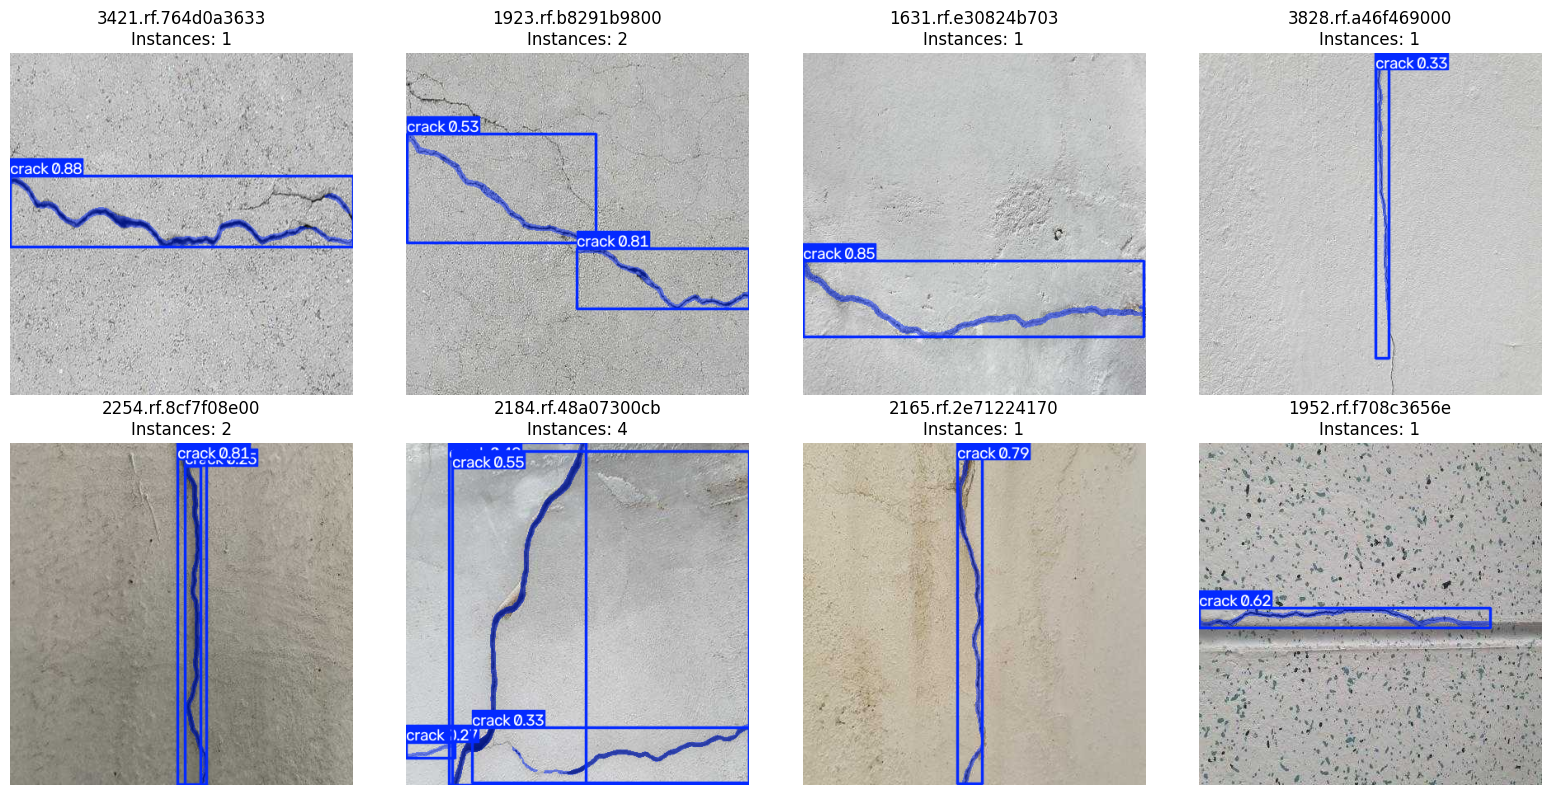

In [18]:
figure, axes = plt.subplots(2, 4, figsize=(16, 8),)

for axis, result in zip(
    axes.flat,
    prediction_results,
):
    plotted_image = result.plot()
    plotted_image = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)

    axis.imshow(plotted_image)

    axis.set_title(
        (
            f"{Path(result.path).stem[:18]}\n"
            f"Instances: "
            f"{len(result.boxes)}"
        )
    )

    axis.axis("off")

plt.tight_layout()

prediction_grid_path = (
    OUTPUT_ROOT
    / "instance_prediction_grid.png"
)

plt.savefig(
    prediction_grid_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()